# SeatWise seating engine - benchmark and walkthrough

SeatWise does not train a model. Its core is an **OR-Tools CP-SAT optimisation engine** that seats every candidate so that

* no two neighbours (8 seats around, diagonals included) write the same paper,
* neighbours' roll numbers are at least *G* apart,
* candidates who need an accessible seat get one,

and, among all valid plans, picks a **seeded random** one that also keeps candidates of the same department apart.

This notebook

1. loads the latest benchmark run (`python -m ml.benchmark`) and shows its results,
2. solves one session live and compares a hall with the usual roll-order seating,
3. demonstrates that a plan is reproducible from its seed.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "backend").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "backend"))
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display

profile = json.loads((ROOT / "models" / "engine_profile.json").read_text())
run_dir = ROOT / "experiments" / profile["experiment"]
metrics = json.loads((run_dir / "metrics.json").read_text())
print("Benchmark run:", metrics["run"], "on", metrics["run_date"])
print("Engine", metrics["engine_version"], "| OR-Tools", metrics["ortools_version"], "| CPU threads", metrics["machine"]["cpu_threads"])
print("Tuned per-hall budget:", profile["hall_budget"])

Benchmark run: engine-benchmark-20260921 on 2026-09-21T12:41:23+00:00
Engine 1.0.0 | OR-Tools 9.15.6755 | CPU threads 12
Tuned per-hall budget: 0.15


## 1. Headline results (typical session of 600 candidates)

In [2]:
pd.Series(metrics["headline"]).to_frame("value")

,value
scenario,m-600
candidates,600
solve_s_mean,2.356453
hard_rules_satisfied_rate,1.0
same_paper_pairs,0.0
conflicts_avoided_vs_sequential,1253.0
abs_roll_seat_correlation,0.06457
neighbour_overlap,0.01014
all_scenarios_solved,True
all_hard_rules_satisfied,True


## 2. Every scenario and method

In [3]:
summary = pd.DataFrame(metrics["summary"])
cols = ["scenario", "method", "solved_rate", "solve_s_mean", "same_paper_pairs_mean", "roll_gap_violations_mean",
        "accessible_violations_mean", "same_department_pairs_mean", "utilisation_mean", "hard_rules_satisfied_rate"]
summary[cols].round(3)

,scenario,method,solved_rate,solve_s_mean,same_paper_pairs_mean,roll_gap_violations_mean,accessible_violations_mean,same_department_pairs_mean,utilisation_mean,hard_rules_satisfied_rate
0,xs-150,SeatWise,1.0,1.253,0.000,0.000,0.000,23.000,0.708,1.0
1,xs-150,Sequential,1.0,0.000,307.000,122.000,3.000,405.000,0.708,0.0
2,xs-150,Round-robin,1.0,0.000,41.000,44.000,3.000,93.000,0.708,0.0
3,xs-150,Random shuffle,1.0,0.000,116.000,21.333,3.000,164.000,0.708,0.0
4,s-300,SeatWise,1.0,2.032,0.000,0.000,0.000,6.667,0.822,1.0
5,s-300,Sequential,1.0,0.000,648.000,231.000,3.000,803.000,1.000,0.0
6,s-300,Round-robin,1.0,0.000,63.000,56.000,3.000,111.000,1.000,0.0
7,s-300,Random shuffle,1.0,0.000,171.000,21.333,3.000,221.000,1.000,0.0
8,m-600,SeatWise,1.0,2.356,0.000,0.000,0.000,108.667,0.957,1.0
9,m-600,Sequential,1.0,0.001,1253.000,453.000,6.000,1648.000,0.971,0.0


### Same-paper neighbours by session size

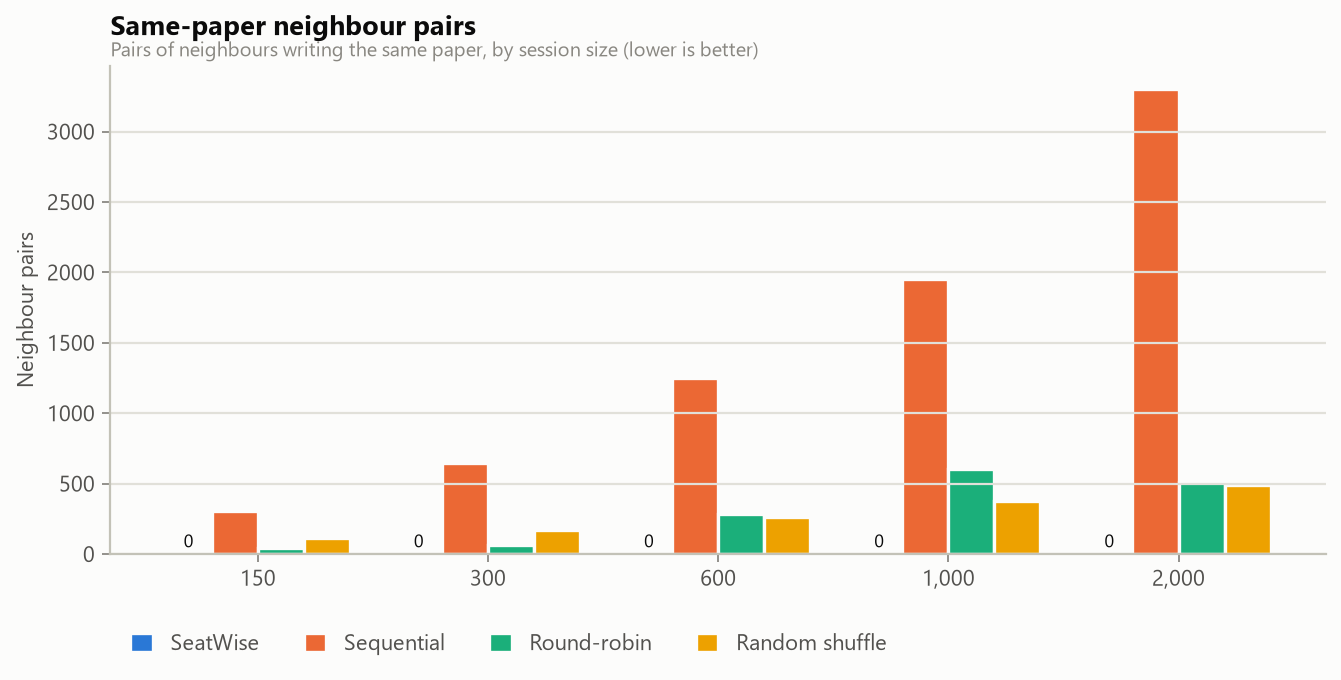

In [4]:
display(Image(filename=str(run_dir / "conflicts_by_method.png")))

### Solve time

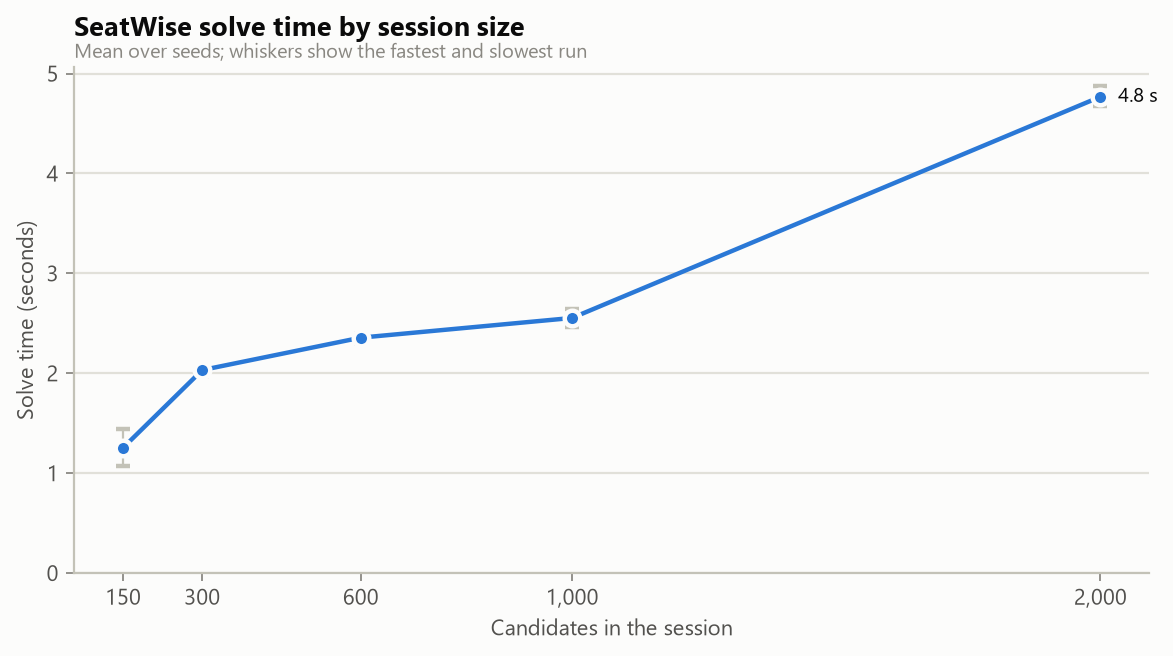

In [5]:
display(Image(filename=str(run_dir / "solve_time_by_size.png")))

### Unpredictability and fairness (many seeds, same session)

,seeds,abs_roll_seat_correlation,neighbour_overlap,front_row_bias_pp
SeatWise,6.0,0.065,0.01,4.711
Sequential,6.0,1.000,1.00,12.364
Round-robin,6.0,0.213,1.00,3.380
Random shuffle,6.0,0.034,0.01,1.636


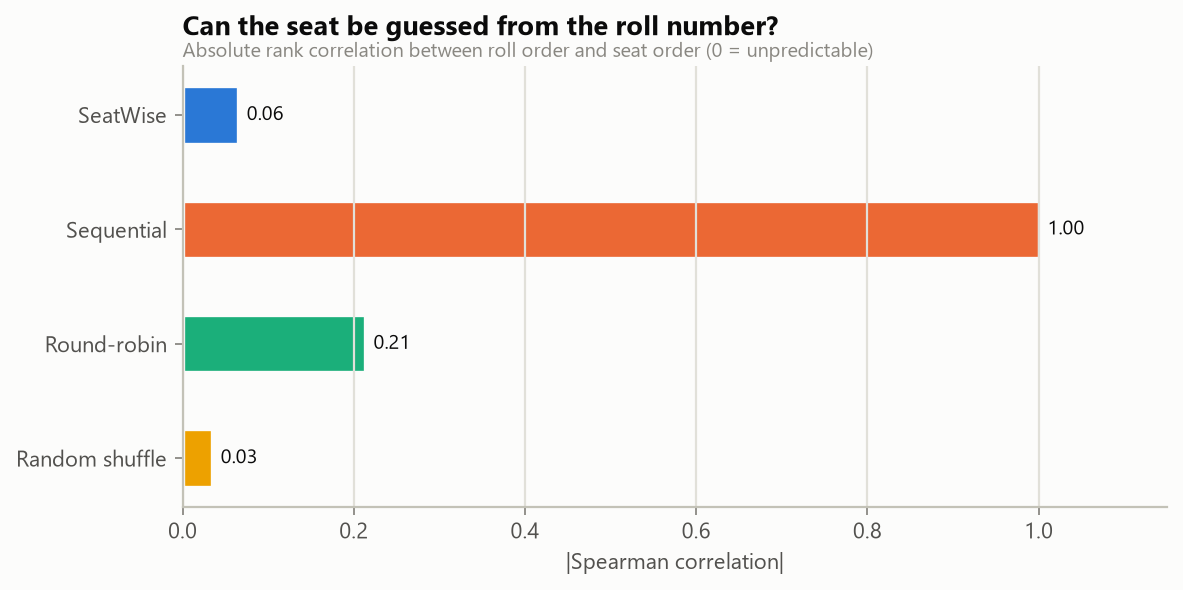

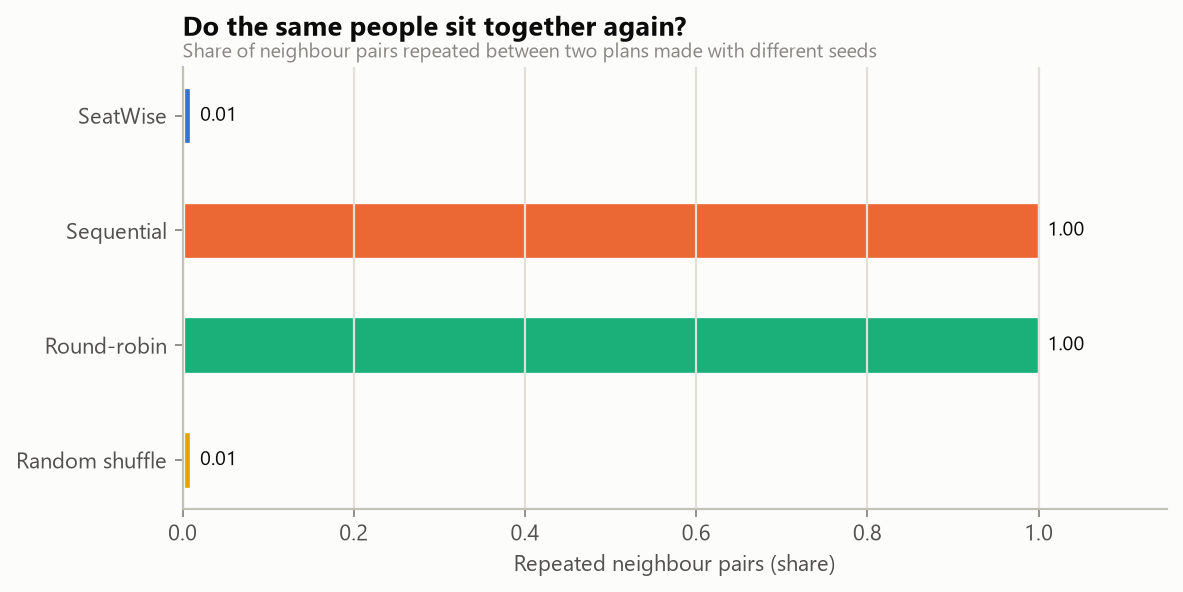

In [6]:
display(pd.DataFrame(metrics["predictability"]).T.round(3))
display(Image(filename=str(run_dir / "roll_seat_correlation.png")))
display(Image(filename=str(run_dir / "neighbour_overlap.png")))

### Department mix and hall utilisation

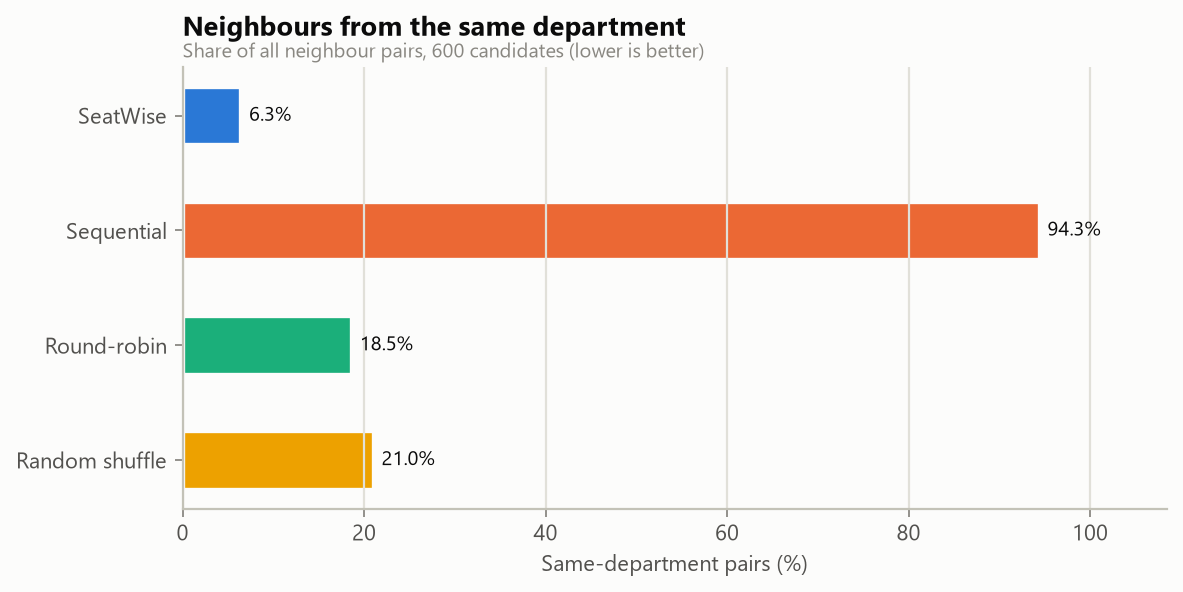

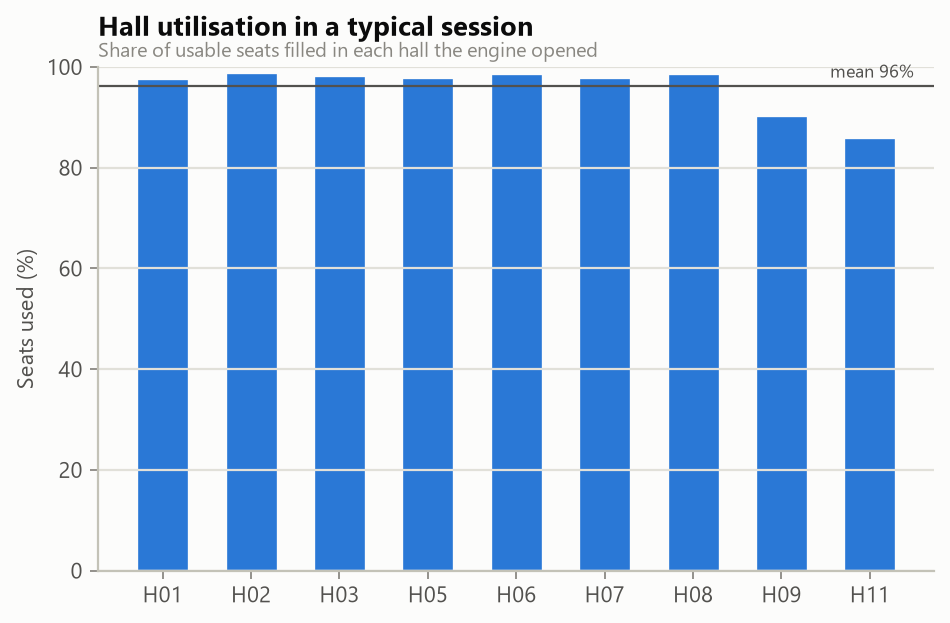

In [7]:
display(Image(filename=str(run_dir / "department_mix_by_method.png")))
display(Image(filename=str(run_dir / "hall_utilisation.png")))

### Per-hall time budget tuning

,budget,all_hard_rules_satisfied,same_department_pairs_mean,session_solve_s_mean
0,0.10,True,127.25,3.717231
1,0.15,True,123.25,2.634991
2,0.25,True,119.25,3.559394
3,0.40,True,116.00,5.012341
4,0.60,True,114.00,6.575243


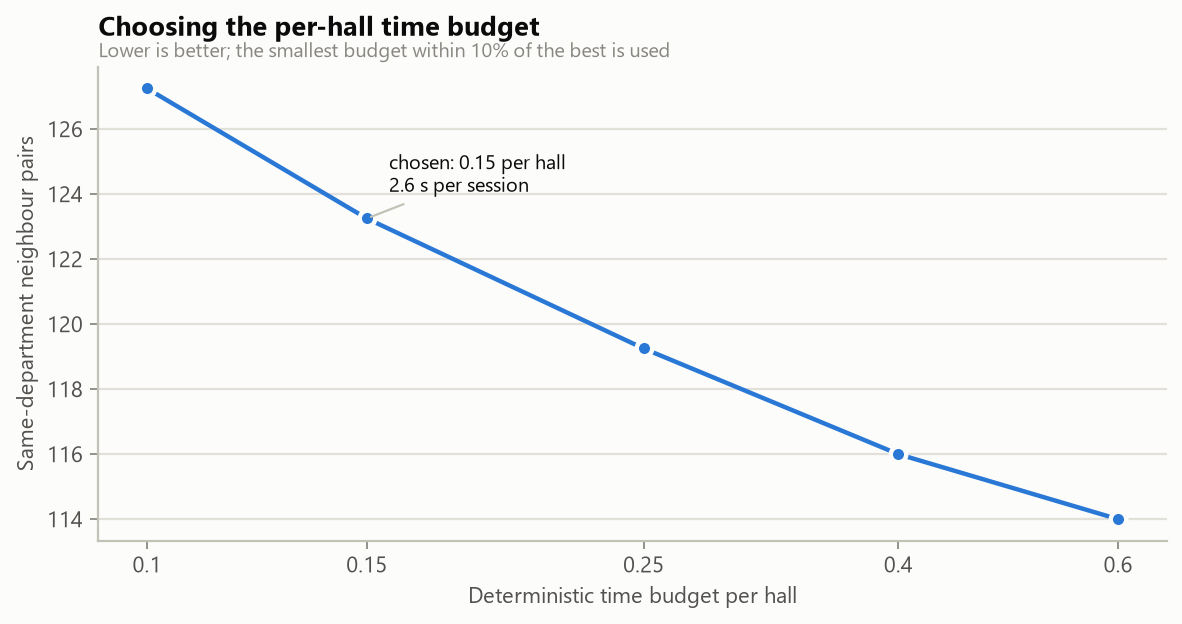

In [8]:
if metrics.get("tuning"):
    display(pd.DataFrame(metrics["tuning"]["budgets"]))
    display(Image(filename=str(run_dir / "budget_tuning.png")))

## 3. Live example

Solve a 300-candidate session and draw one hall. Each colour is a paper; the engine never lets two neighbours share one.
The right-hand grid is the same hall filled in roll-number order - red outlines mark candidates sitting next to someone with the same paper.

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from app.services.engine import solve, validate
from app.services.engine.baselines import sequential
from app.services.engine.graph import seat_neighbours
from ml.scenarios import build, spec_by_name

scenario = build(spec_by_name("s-300"))
result = solve(scenario.candidates, scenario.halls, scenario.rules, seed=2026)
card = validate(scenario.candidates, scenario.halls, result.placements, scenario.rules)
base = sequential(scenario.candidates, scenario.halls, scenario.rules)
base_card = validate(scenario.candidates, scenario.halls, base, scenario.rules)
print(f"SeatWise: solved in {result.solve_ms} ms, same-paper pairs {card.same_paper_pairs}, roll-gap violations {card.roll_gap_violations}")
print(f"Roll order: same-paper pairs {base_card.same_paper_pairs}, roll-gap violations {base_card.roll_gap_violations}")

SeatWise: solved in 2022 ms, same-paper pairs 0, roll-gap violations 0
Roll order: same-paper pairs 648, roll-gap violations 231


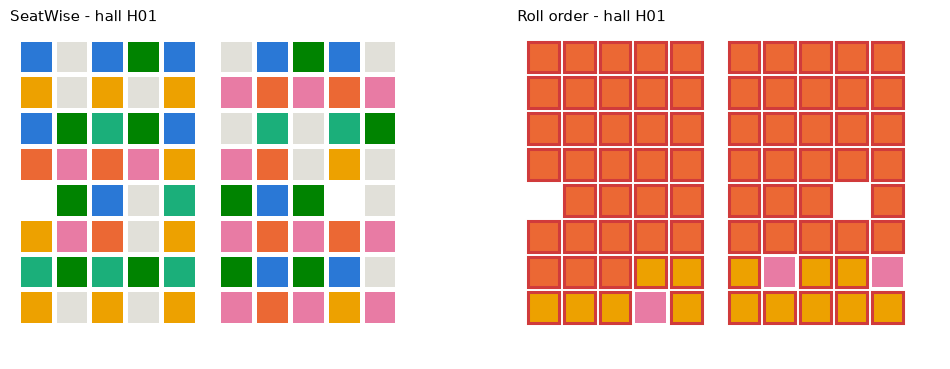

In [10]:
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
paper_of = {c.key: c.paper for c in scenario.candidates}
papers = sorted({c.paper for c in scenario.candidates})
colour = {p: PALETTE[i % len(PALETTE)] for i, p in enumerate(papers)}

def draw(ax, hall, placements, title):
    seated = {(p.row, p.col): paper_of[p.candidate] for p in placements if p.hall == hall.key}
    around = seat_neighbours(hall, scenario.rules.adjacency)
    for (r, c) in hall.seats:
        paper = seated.get((r, c))
        clash = paper and any(seated.get(n) == paper for n in around[(r, c)])
        x = c + sum(1 for a in hall.aisles_after if c >= a) * 0.6
        ax.add_patch(Rectangle((x, -r), 0.86, 0.86, facecolor=colour[paper] if paper else "#e1e0d9",
                               edgecolor="#d03b3b" if clash else "none", linewidth=2.2))
    ax.set_xlim(-0.3, hall.cols + 1.5); ax.set_ylim(-hall.rows, 1.2); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, loc="left", fontsize=11)

hall = next(h for h in scenario.halls if any(p.hall == h.key for p in result.placements))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw(axes[0], hall, result.placements, f"SeatWise - hall {hall.key}")
draw(axes[1], hall, base, f"Roll order - hall {hall.key}")
plt.show()

## 4. Reproducible from the seed

The seed is stored with every plan. Solving the same inputs with the same seed gives exactly the same plan, so anyone can verify a plan was not hand-picked; a different seed gives a different, equally valid plan.

In [11]:
import hashlib

def fingerprint(placements):
    text = "|".join(f"{p.candidate}:{p.hall}:{p.row}:{p.col}" for p in sorted(placements, key=lambda p: p.candidate))
    return hashlib.sha256(text.encode()).hexdigest()[:16]

again = solve(scenario.candidates, scenario.halls, scenario.rules, seed=2026)
other = solve(scenario.candidates, scenario.halls, scenario.rules, seed=2027)
moved = sum(a != b for a, b in zip(sorted((p.candidate, p.hall, p.row, p.col) for p in result.placements),
                                   sorted((p.candidate, p.hall, p.row, p.col) for p in other.placements)))
print("seed 2026:", fingerprint(result.placements))
print("seed 2026 again:", fingerprint(again.placements), "-> identical" if fingerprint(again.placements) == fingerprint(result.placements) else "-> DIFFERENT")
print("seed 2027:", fingerprint(other.placements), f"-> {moved} of {len(result.placements)} candidates in a different seat")

seed 2026: fb7455c7233015a6
seed 2026 again: fb7455c7233015a6 -> identical
seed 2027: c3da4dab8cb3519c -> 299 of 300 candidates in a different seat


## Re-running the benchmark

```bat
venv\Scripts\python -m ml.benchmark           :: full run with budget tuning (writes a new experiments/ folder and models/engine_profile.json)
venv\Scripts\python -m ml.benchmark --quick   :: small smoke run
```